
## FINANCIAL DATA
MODULE 4 | LESSON 2


---


# **OPTION DEPENDENCIES**

|  |  |
|:---|:---|
|**Reading Time** |  40-60 minutes |
|**Prior Knowledge** |Python package opstrat, Python package optionprice, ATM, ITM, OTM, Analytic   |
|**Keywords** |Option Dependencies, Early Exercise, Stochastic Dominance   |


---
<span style='color: transparent; font-size:1%'>All rights reserved WQU WorldQuant University QQQQ</span>

*In the previous lesson, we covered the basics of option payoffs for single and multiple option strategies. In this lesson, we examine how options depend on their various components: stock prices, expiry times, volatilities, and interest rates.*  

In [1]:
import matplotlib.patches as mpatches
import QuantLib as ql
from matplotlib import pyplot as plt

## 1. Option Pricing Functions

Recall from the previous lesson that we used the Python package `QuantLib` in order to price European vanilla calls and puts. At this notebook, we are introducing a second function in order to price American vanilla options.

In [2]:
def option_price_european(
    S0, K, days_to_maturity, r, sigma, call=True, engine="BS", steps=200, paths=10000
):
    """
    This function returns the price of a European Call with 3 different price engines: BS, BT and MC.
    """

    # Setting up the dates
    today = ql.Date().todaysDate()
    maturity = today + days_to_maturity

    # Choosing the type of the option
    if call:
        option_type = ql.Option.Call
    else:
        option_type = ql.Option.Put

    # Creating the payoff
    payoff = ql.PlainVanillaPayoff(option_type, K)

    europeanExercise = ql.EuropeanExercise(maturity)
    europeanOption = ql.VanillaOption(payoff, europeanExercise)

    # Setting up the option's characteristics
    spot = ql.SimpleQuote(S0)
    riskFreeTS = ql.YieldTermStructureHandle(
        ql.FlatForward(today, r, ql.Actual365Fixed())
    )
    volTS = ql.BlackVolTermStructureHandle(
        ql.BlackConstantVol(today, ql.NullCalendar(), sigma, ql.Actual365Fixed())
    )

    # We will use the analytical way of pricing the options
    process = ql.BlackScholesProcess(ql.QuoteHandle(spot), riskFreeTS, volTS)

    if engine == "BS":
        engine = ql.AnalyticEuropeanEngine(process)
    elif engine == "BT":
        engine = ql.BinomialVanillaEngine(process, "crr", steps)
    elif engine == "MC":
        engine = ql.MCEuropeanEngine(
            process, "PseudoRandom", timeSteps=steps, requiredSamples=paths
        )
    europeanOption.setPricingEngine(engine)

    return europeanOption.NPV()  # NPV stands for Net Present Value

In [3]:
def option_price_american(S0, K, days_to_maturity, r, sigma, call=True, steps=300):
    """
    This Function returns the price of an American option using a binomial tree
    """
    # Setting up the dates
    today = ql.Date().todaysDate()
    maturity = today + days_to_maturity

    # Choosing the type of the option
    if call:
        option_type = ql.Option.Call
    else:
        option_type = ql.Option.Put

    # Creating the payoff
    payoff = ql.PlainVanillaPayoff(option_type, K)

    americanExercise = ql.AmericanExercise(today, maturity)
    americanOption = ql.VanillaOption(payoff, americanExercise)

    # Setting up the option's characteristics
    spot = ql.SimpleQuote(S0)
    riskFreeTS = ql.YieldTermStructureHandle(
        ql.FlatForward(today, r, ql.Actual365Fixed())
    )
    volTS = ql.BlackVolTermStructureHandle(
        ql.BlackConstantVol(today, ql.NullCalendar(), sigma, ql.Actual365Fixed())
    )
    process = ql.BlackScholesProcess(ql.QuoteHandle(spot), riskFreeTS, volTS)

    # We will use a binomial tree in order to price the american options
    engine = ql.BinomialVanillaEngine(process, "crr", steps)
    americanOption.setPricingEngine(engine)
    return americanOption.NPV()

## 2. Comparing Option Prices to Stock Prices
Now, let's define a wrapper function to the opstrat function Option. We want to price an option using different stock prices, but keeping all other variables the same.
Our `CallOptionVsStock()` function will use default values for everything except the stock price.
It is not our intent to write a very general function, but just one that can help create plots that show how the option price varies with the underlying stock price.

In [4]:
def CallOptionVsStock(S, K=100, t=30, sigma=0.20, r=0.05):
    myCall = round(
        option_price_european(
            S, K, t, r, sigma, call=True, engine="BS", steps=200, paths=10000
        ),
        4,
    )
    return myCall

This is an easy function to understand. We give it a descriptive, albeit somewhat long, function name that indicates we will be able to price options given stock prices.


We'll define two more simple functions. First, we'll define a function, `getCallPayoff()`, that determines the call's payoff, which is the non-negative value of S-K or 0.

Second, we'll define a function, `addCallPayoff()`, that will add the call payoff to the price chart. Note, in `addCallPayoff()`, we take advantage of the Python function map, by mapping the `getCallPayoff()` function over each of the stock prices, and storing the results in a list of option prices.

Just like data frames, these data structures should be familiar. Please see the required reading on lists in the textbook.


In [5]:
def getCallPayoff(S, K=100):
    if S > K:
        return S - K
    return 0


def addCallPayoff(K, rng=21):
    stockP = range(K - 21, K + 21)
    OptionP = list(map(getCallPayoff, stockP))
    plt.plot(stockP, OptionP, linestyle="dotted")

Next, we create a list of the stock prices.  To create a smooth graph, we would like to have, say, about 40 different stock prices.  So we'll create a sequence of stock prices that span values centered around the strike level. Suppose the strike is 90.  We'll have stock prices at 70, 71, 72, ..., 90, 91, ..., 108, 109, and 110.  Likewise, we'll initialize a list of the option prices. Again, we make good use of the map function by mapping the `CallOptionVsStock()` function over each of the stock prices and storing the results in a list of option prices.

In [6]:
StockPrices = list(range(80, 120))
OptionPrices = list(map(CallOptionVsStock, StockPrices))

It's time to graph. Let's use the `matplotlib` package. Please read the chapter in *Quantitative Economics* to understand this extremely useful package for graphing.

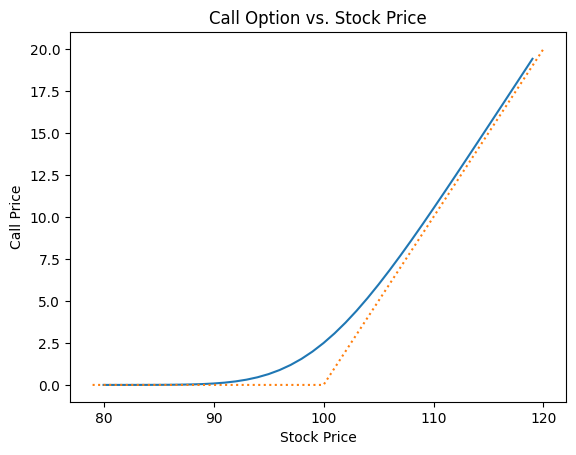

In [7]:
plt.plot(StockPrices, OptionPrices)
plt.title("Call Option vs. Stock Price")
plt.xlabel("Stock Price")
plt.ylabel("Call Price")
addCallPayoff(100)

Be sure to distinguish between the two curves. The blue line represents the option's price. The price applies during the option's lifetime. The orange line represents the option's payoff. The payoff applies only at the option's expiration.

Let's repeat the same process for puts. First, we'll define functions for `PutOptionsVsStock()`, `getPutPayoff()`, and `addPutPayoff()`.

In [8]:
def PutOptionVsStock(S, K=100, t=30, sigma=0.20, r=0.05):
    myPut = round(
        option_price_european(
            S, K, t, r, sigma, call=False, engine="BS", steps=200, paths=10000
        ),
        4,
    )
    return myPut


def getPutPayoff(S, K=100):
    if S < K:
        return K - S
    return 0


def addPutPayoff(K, rng=21):
    stockP = range(K - 21, K + 21)
    optionP = list(map(getPutPayoff, stockP))
    plt.plot(stockP, optionP, linestyle="dotted")

Now we can reuse the list of the stock prices, ranging 20% from the strike.

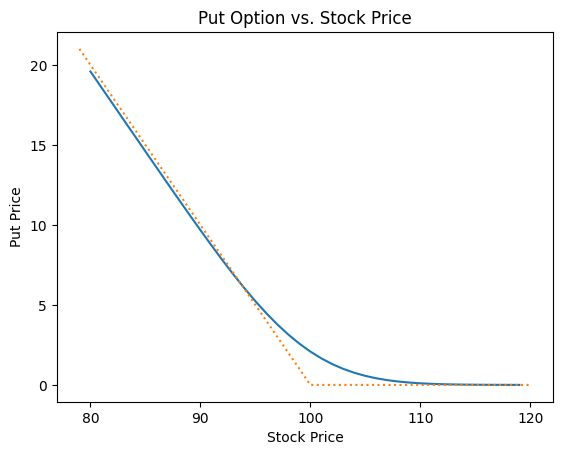

In [9]:
StockPrices = list(range(80, 120))
OptionPrices = list(map(PutOptionVsStock, StockPrices))

plt.plot(StockPrices, OptionPrices)
plt.title("Put Option vs. Stock Price")
plt.xlabel("Stock Price")
plt.ylabel("Put Price")
addPutPayoff(100)

## 3. Time Value of Calls and Puts
In each of these plots, the orange dotted line represents the option's payoff. This is the value of the option at expiration. The blue line represents the option's price.
There is a subtle point to notice regarding the relative location. When we are out of the money, the blue line exceeds the option payoff. Why?

Recall from Module 4 in Financial Markets that an option's value equals its intrinsic value plus its time value.
Out-of-the-money options do not have intrinsic value. All their value comes from having more time.

Generally, more time means more chances to get in the money!

However, look at the difference when in the money.
In fact, the effect will be even more pronounced if we increase the time to expiration.


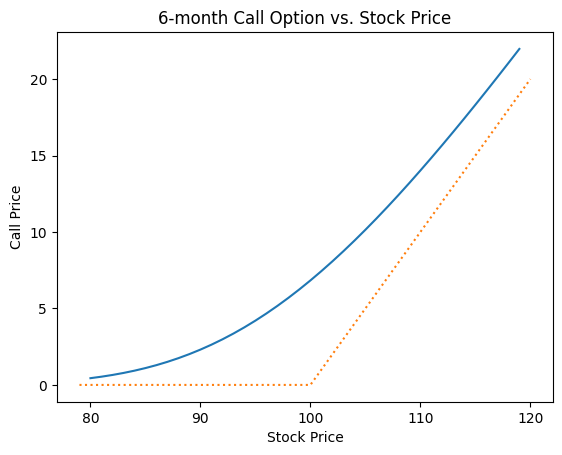

In [10]:
def CallOptionVsStock(S, K=100, t=180, sigma=0.20, r=0.05):
    myCall = round(
        option_price_european(
            S, K, t, r, sigma, call=True, engine="BS", steps=200, paths=10000
        ),
        4,
    )
    return myCall


OptionPrices = list(map(CallOptionVsStock, StockPrices))
plt.plot(StockPrices, OptionPrices)
plt.title("6-month Call Option vs. Stock Price")
plt.xlabel("Stock Price")
plt.ylabel("Call Price")
addCallPayoff(100)

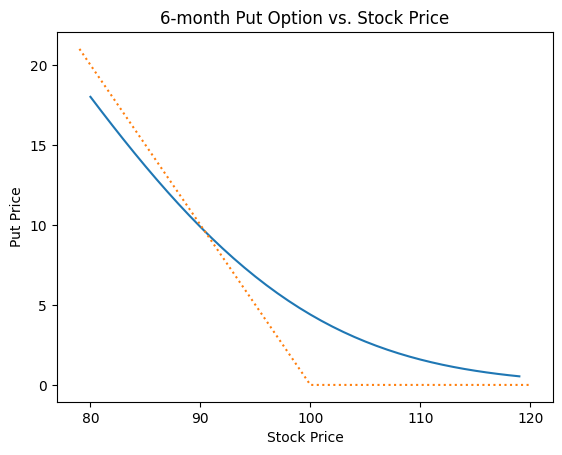

In [11]:
def PutOptionVsStock(S, K=100, t=180, sigma=0.20, r=0.05):
    myPut = round(
        option_price_european(
            S, K, t, r, sigma, call=False, engine="BS", steps=200, paths=10000
        ),
        4,
    )
    return myPut


OptionPrices = list(map(PutOptionVsStock, StockPrices))
plt.plot(StockPrices, OptionPrices)
plt.title("6-month Put Option vs. Stock Price")
plt.xlabel("Stock Price")
plt.ylabel("Put Price")
addPutPayoff(100)

## 4. Time Value Can Hurt European Puts
With more time, a significant difference appears. Recall that

$$\text{option value} = \text{intrinsic value} + \text{time value}$$

The option value is the blue curve. The intrinsic value is the orange curve; it is the same as the payoff. The time value is therefore the vertical distance between these two curves.

$$\text{time value} = \text{option value} - \text{intrinsic value}$$

For a deep in-the-money (ITM) call, the time value is positive. In other words, the blue curve (option price) exceeds the orange curve (option payoff). More time for a call can lead to higher payoffs. Calls have unlimited payoffs.

However, for a deep ITM put, the time value is negative. In other words, the blue curve (option price) is less than the orange curve (option payoff). More time for a put may not be good. Why?

Remember that the exercise style is European. When a put is deep ITM, we would probably want to exercise right away.

If we could, we would collect the difference between the strike and stock, and we can invest those proceeds at the risk-free rate. Unlike long calls, long put positions have a bounded profit. The most they could make is the strike, and that assumes the stock prices go to zero. If we were able to exercise that sooner (as in an American exercise style) rather than later (as in a European exercise style), we could earn even more by earning the risk-free rate. But all the graphs we have presented here are for European options. This is the beauty of graphing.


## 5. Difference between European and American Puts

So what if we switched the exercise style to American?
We have to make a few changes.

First, we'll define a new function, `AmericanPutOptionVsStock()`, that uses the American style of exercise.
Second, we have to use a different pricing methodology.  Due to the path-dependence of the American option, we have no analytical solution to price it.  Instead, we can only use a numerical solution.  In this case, we'll use binomial trees, with a small number of iterations, so we can produce the graph quickly.

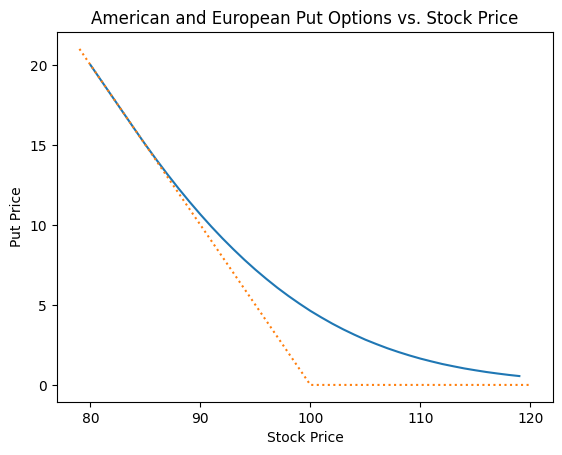

In [12]:
def AmericanPutOptionVsStock(S, K=100, t=180, sigma=0.20, r=0.05):
    myPut = option_price_american(S, K, t, r, sigma, call=False, steps=300)
    return myPut


OptionPrices = list(map(AmericanPutOptionVsStock, StockPrices))

# Graph the American option
plt.plot(StockPrices, OptionPrices)
plt.title("American and European Put Options vs. Stock Price")
plt.xlabel("Stock Price")
plt.ylabel("Put Price")
addPutPayoff(100)

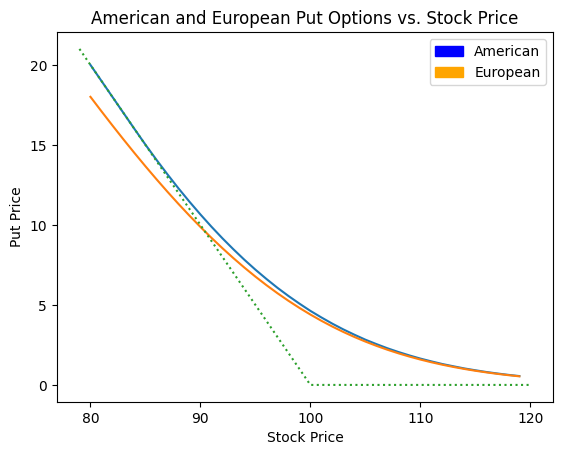

In [13]:
# Graph the American option
plt.plot(StockPrices, OptionPrices)

# Graph the European option
plt.plot(StockPrices, list(map(PutOptionVsStock, StockPrices)))

# Add titles, payoff, labels and a legend
plt.title("American and European Put Options vs. Stock Price")
addPutPayoff(100)
plt.xlabel("Stock Price")
plt.ylabel("Put Price")
patch1 = mpatches.Patch(color="blue", label="American")
patch2 = mpatches.Patch(color="orange", label="European")
plt.legend(handles=[patch1, patch2]);

Notice how the American option's value is always above the payoff.
Notice how the European option's value is not above the payoff when it is deep ITM.
Conceptually, this is critical.
This means there is never a time value that hurts the American option because the option can simply be exercised early.
But there is a time value that hurts the European option because its price is actually less than its payoff is, simply because early exercise is prohibited.
When the put is deep ITM, it would make sense to exercise early, and that is why the option's price is basically its payoff value.
When the put is close to ATM or OTM, there is very little difference between the two options.

Another important finding is that we can see an important mathematical relationship. Mathematically, the American option stochastically dominates the European option.  Stochastic dominance is an important tool that will show up in later courses. In layman's terms, it is always better to have the American option than the European option because it is always worth at least as much as the European option and in some cases, it's worth more.  

This example demonstrates how Python can be used to not only examine basic payoffs and prices but also to understand more complex and elusive relationships that exist between options and their sensitivities and exercise styles.  

Think of Python as a tool that allows you to get deeper into the mathematics, relationships, and intricacies of options. This module focuses on options, but imagine how Python can do this for all areas of this program.  

Indeed, as a financial engineer, you will be "engineering" models. Even before you get deep into the data, it helps to understand how the models work. For our program, the primary language you will use to create these models is Python. Of course, you could build models in R or Julia or C#, but it is beneficial to focus on one first. That is, it helps to be proficient and fluent in a single language rather than just having some knowledge in a lot of languages.

Be sure to study not only the behavior of options here but also how Python is being used to illustrate this behavior.  From this point forward, every course will require you to work with Python, including reading other code, modifying existing code, creating your own code and debugging it, and learning to use numerous packages and frameworks.  

However, learning Python is not the end goal because you are trying to do more than become a Python programmer. You are using Python as a tool to engineer models that provide solutions to pricing, hedging, and allocation problems in many different asset classes.

We'll continue this illustration by graphing how the option price depends on the time to expiration.

## 6. Time Value of Options

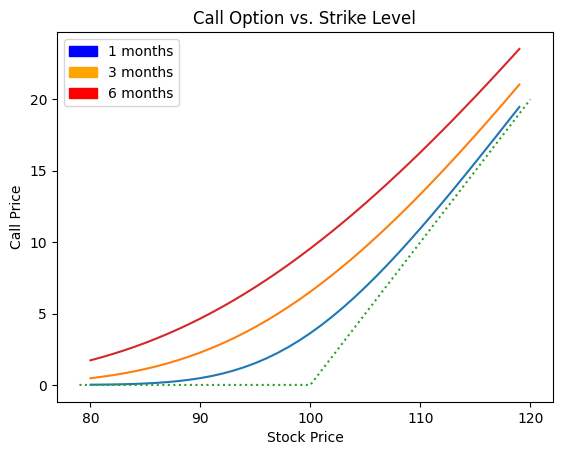

In [14]:
StockPrices = list(range(80, 120))


def CallOptionVsStock(S, K=100, t=30, sigma=0.30, r=0.05):
    myCall = option_price_european(
        S, K, t, r, sigma, call=True, engine="BS", steps=200, paths=10000
    )
    return myCall


OptionPrices = list(map(CallOptionVsStock, StockPrices))
plt.plot(StockPrices, OptionPrices)
plt.title("Call Option vs. Strike Level")
plt.xlabel("Stock Price")
plt.ylabel("Call Price")


def CallOptionVsStock(S, K=100, t=90, sigma=0.30, r=0.05):
    myCall = option_price_european(
        S, K, t, r, sigma, call=True, engine="BS", steps=200, paths=10000
    )
    return myCall


OptionPrices = list(map(CallOptionVsStock, StockPrices))
plt.plot(StockPrices, OptionPrices)
addCallPayoff(100)


def CallOptionVsStock(S, K=100, t=180, sigma=0.30, r=0.05):
    myCall = option_price_european(
        S, K, t, r, sigma, call=True, engine="BS", steps=200, paths=10000
    )
    return myCall


OptionPrices = list(map(CallOptionVsStock, StockPrices))
plt.plot(StockPrices, OptionPrices)
patch1 = mpatches.Patch(color="blue", label="1 months")
patch2 = mpatches.Patch(color="orange", label="3 months")
patch3 = mpatches.Patch(color="red", label="6 months")
plt.legend(handles=[patch1, patch2, patch3]);

With more time to expiry, the call options increase in value. Therefore, 6-month call options are more valuable than 3-month call options, which are more valuable than 1-month call options.

For puts, ATM and OTM behave like calls, but deep ITM options are virtually indistinguishable from each other and have negative time value.


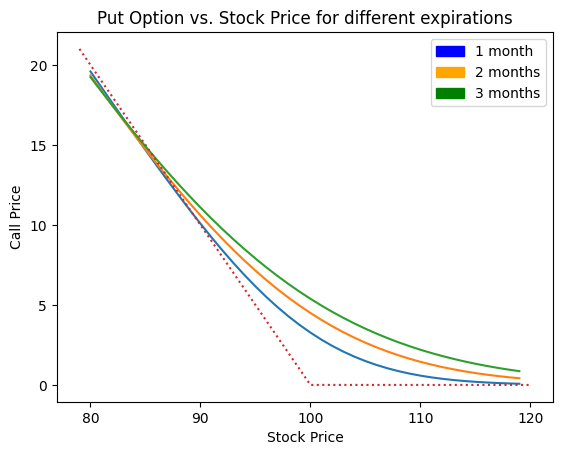

In [15]:
StockPrices = list(range(80, 120))


def PutOptionVsStock(S, K=100, t=31, sigma=0.30, r=0.05):
    myPut = option_price_european(
        S, K, t, r, sigma, call=False, engine="BS", steps=200, paths=10000
    )
    return myPut


plt.plot(StockPrices, list(map(PutOptionVsStock, StockPrices)))
plt.title("Put Option vs. Stock Price for different expirations")
plt.xlabel("Stock Price")
plt.ylabel("Call Price")


def PutOptionVsStock(S, K=100, t=62, sigma=0.30, r=0.05):
    myPut = option_price_european(
        S, K, t, r, sigma, call=False, engine="BS", steps=200, paths=10000
    )
    return myPut


plt.plot(StockPrices, list(map(PutOptionVsStock, StockPrices)))


def PutOptionVsStock(S, K=100, t=93, sigma=0.30, r=0.05):
    myPut = option_price_european(
        S, K, t, r, sigma, call=False, engine="BS", steps=200, paths=10000
    )
    return myPut


plt.plot(StockPrices, list(map(PutOptionVsStock, StockPrices)))
addPutPayoff(100)
patch1 = mpatches.Patch(color="blue", label="1 month")
patch2 = mpatches.Patch(color="orange", label="2 months")
patch3 = mpatches.Patch(color="green", label="3 months")
plt.legend(handles=[patch1, patch2, patch3]);

## 7. Option Prices for Different Volatilities

We've compared options with different expirations. Now let's compare options with different volatilities.

Before writing code like we did in the last section, notice the duplication in the functions. `CallOptionVsStock()` was written as a new function each time, and we simply changed some of the default arguments because map was already iterating over S. Ideally, we'd like the map function to iterate over more than just one argument. We can easily iterate over other lists if we pass additional arguments to map.

Let's write `CallOptionVsStock()` to take two required arguments: the stock price and the volatility. Then, we'll pass lists (of the appropriate length) to the map function.

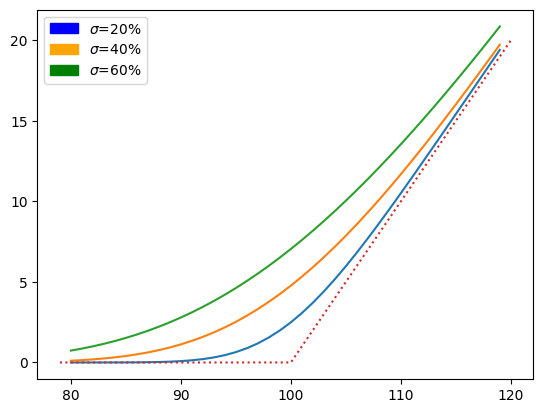

In [16]:
def CallOptionVsStock(S, sigma, K=100, t=30, r=0.05):
    myCall = option_price_european(
        S, K, t, r, sigma, call=True, engine="BS", steps=200, paths=10000
    )
    return myCall


for i in range(1, 4):
    sigmas = [0.20 * i] * len(StockPrices)
    OptionPrices = list(map(CallOptionVsStock, StockPrices, sigmas))
    plt.plot(StockPrices, OptionPrices)

patch1 = mpatches.Patch(color="blue", label=r"$\sigma$=20%")
patch2 = mpatches.Patch(color="orange", label=r"$\sigma$=40%")
patch3 = mpatches.Patch(color="green", label=r"$\sigma$=60%")
plt.legend(handles=[patch1, patch2, patch3])
addCallPayoff(100)

Notice two features.
1. The higher the volatility, the greater the option's value.  This is true at all locations: ITM, ATM, and OTM.
2. The difference is more pronounced when we are close to the strike and less so when we are either deep OTM or deep ITM. In other words, the lines are maximally separated when we are closer to the strike level of 100; the lines are closer together when we are further from the strike, in either direction.

Let's see how puts behave. It turns out they behave the same.

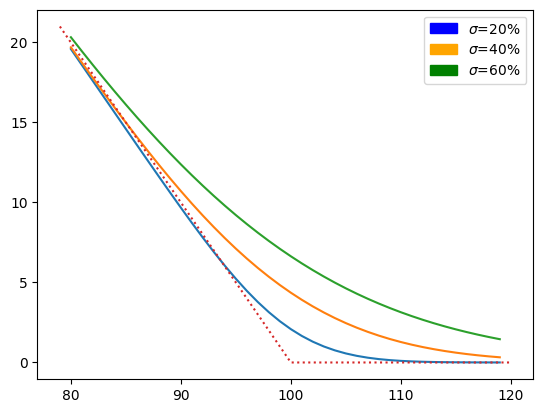

In [17]:
def PutOptionVsStock(S, sigma, K=100, t=30, r=0.05):
    myPut = option_price_european(
        S, K, t, r, sigma, call=False, engine="BS", steps=200, paths=10000
    )
    return myPut


for i in range(1, 4):
    sigmas = [0.20 * i] * len(StockPrices)
    OptionPrices = list(map(PutOptionVsStock, StockPrices, sigmas))
    plt.plot(StockPrices, OptionPrices)

patch1 = mpatches.Patch(color="blue", label=r"$\sigma$=20%")
patch2 = mpatches.Patch(color="orange", label=r"$\sigma$=40%")
patch3 = mpatches.Patch(color="green", label=r"$\sigma$=60%")
plt.legend(handles=[patch1, patch2, patch3])
addPutPayoff(100)

When you are long a vanilla option (call or put), volatility is your friend.  The greater the volatility, the greater the option is worth.

## 8. Option Prices for Different Interest Rates

Let's examine one more sensitivity: how the option prices vary with interest rates.
Imagine we have three different interest rates: 5%, 10%, and 15%:

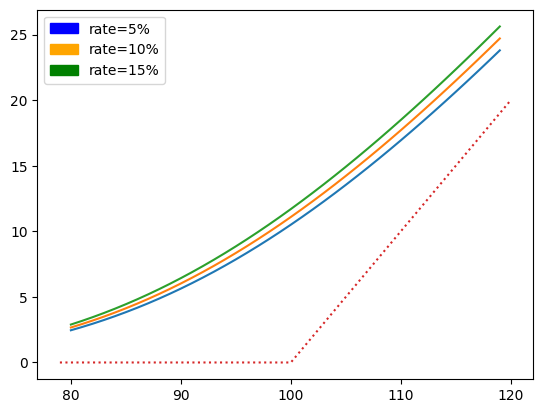

In [18]:
def CallOptionVsStock(S, r, K=100, t=91, sigma=0.50):
    myCall = option_price_european(
        S, K, t, r, sigma, call=True, engine="BS", steps=200, paths=10000
    )
    return myCall


for i in range(1, 4):
    rates = [0.05 * i] * len(StockPrices)
    OptionPrices = list(map(CallOptionVsStock, StockPrices, rates))
    plt.plot(StockPrices, OptionPrices)

patch1 = mpatches.Patch(color="blue", label="rate=5%")
patch2 = mpatches.Patch(color="orange", label="rate=10%")
patch3 = mpatches.Patch(color="green", label="rate=15%")
plt.legend(handles=[patch1, patch2, patch3])
addCallPayoff(100)

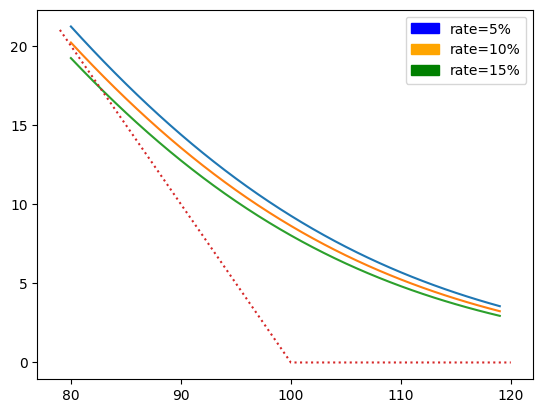

In [19]:
def PutOptionVsStock(S, r, K=100, t=91, sigma=0.50):
    myPut = option_price_european(
        S, K, t, r, sigma, call=False, engine="BS", steps=200, paths=10000
    )
    return myPut


for i in range(1, 4):
    rates = [0.05 * i] * len(StockPrices)
    OptionPrices = list(map(PutOptionVsStock, StockPrices, rates))
    plt.plot(StockPrices, OptionPrices)

patch1 = mpatches.Patch(color="blue", label="rate=5%")
patch2 = mpatches.Patch(color="orange", label="rate=10%")
patch3 = mpatches.Patch(color="green", label="rate=15%")
plt.legend(handles=[patch1, patch2, patch3])
addPutPayoff(100)

Notice the difference!  For call options, the green curve is above the orange curve, which is above the blue curve.  In other words, the higher the interest rate, the more valuable the call option.

For put options, the blue curve is above the orange curve, which is above the green curve. In other words, the lower the interest rate, the more valuable the put option.

Using Python, we visually conclude some stylized facts about options:
1. More volatility makes calls and puts more valuable.
2. More time tends to make calls and puts more valuable: however, more time may be detrimental to deep ITM puts.
3. Higher interest rates make calls more expensive and make puts less expensive.

Of course, in the "Derivative Pricing" course, we will examine these sensitivities using analytical mathematics by defining partial derivatives and labeling them with their appropriate Greek notation. For now, the idea is that Python computations can lead to understanding stylized facts.

## 9. Conclusion

In this lesson, we examined how options depend on their various components: stock prices, expiry times, volatilities, and interest rates. In the next lesson, we'll learn how to import option prices into Python.

---
Copyright 2024 WorldQuant University. This
content is licensed solely for personal use. Redistribution or
publication of this material is strictly prohibited.
